In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

Cette section configure notre laboratoire numérique en chargeant les outils essentiels pour modéliser la dynamique du Mpox. Les bibliothèques initiales (pandas, numpy, seaborn) permettent de structurer et de visualiser les interactions entre les facteurs environnementaux et le nombre de cas. Les modules de scikit-learn préparent les données (normalisation, découpage train/test) pour isoler les facteurs de risque via différents algorithmes de régression (linéaire, Ridge, Lasso, Random Forest). Enfin, les fonctions métriques évaluent la précision mathématique du modèle, garantissant la fiabilité des prédictions et la robustesse des conclusions épidémiologiques.

In [2]:
# ==============================================================================
# ÉTAPE 1 : CHARGEMENT DES DONNÉES ET ANALYSE EXPLORATOIRE (EDA)
# ==============================================================================
print("\n" + "="*70)
print("ANALYSE EXPLORATOIRE APPROFONDIE (EDA) - MPOX RDC")
print("="*70)


ANALYSE EXPLORATOIRE APPROFONDIE (EDA) - MPOX RDC


In [5]:
import pandas as pd
import numpy as np
# ... le reste des imports

In [6]:
# 1.1. Chargement du fichier avec votre vrai chemin
df = pd.read_csv("D:/MASG_M2/Pratique_data_science/Data_science_first/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv")

In [4]:
# 1.2. Statistiques descriptives basées sur vos vraies variables numériques
print("\n Statistiques descriptives des variables numériques :")
variables_num = ['Cas_Confirmes', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 
                 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 
                 'Tests_Realises', 'Distance_Centre_Sante_km', 'Taux_Positivite_pct']
print(df[variables_num].describe())


 Statistiques descriptives des variables numériques :
       Cas_Confirmes  Pluviometrie_mm  Temperature_C         NDVI  \
count    3000.000000      3000.000000    3000.000000  3000.000000   
mean       79.603333       157.779667      24.980367     0.451182   
std        70.119799       101.958774       3.832510     0.157799   
min         0.000000         2.000000      18.000000     0.103000   
25%        29.000000        77.000000      22.300000     0.331000   
50%        57.000000       136.000000      24.900000     0.452000   
75%       109.000000       221.000000      27.600000     0.576000   
max       479.000000       400.000000      34.000000     0.795000   

       Humidite_pct  Densite_Population  Couverture_Vaccinale_pct  \
count   3000.000000         3000.000000               3000.000000   
mean      71.571667          119.100333                 31.843967   
std       11.625285           95.218460                 14.079517   
min       40.000000            5.000000        

1. Profil épidémiologique de la maladie (Mpox)

    Intensité et hétérogénéité de la transmission : En moyenne, on enregistre environ 80 cas confirmés par observation (mean = 79.6). Cependant, l'écart-type très élevé (std = 70.1) et l'écart immense entre le minimum (0 cas) et le maximum (479 cas) révèlent une distribution fortement asymétrique. La médiane (50%) se situant à 57 cas, cela indique que la majorité des zones rapportent des chiffres modérés, mais que l'épidémie est tirée vers le haut par des pics épidémiques majeurs ou des super-événements de transmission (les valeurs allant de 109 à 479 cas).

    Alerte sur la positivité : Le taux de positivité moyen est extrêmement préoccupant, s'élevant à 27.04 %. Dans les situations les plus critiques (max), il atteint 95 %. En épidémiologie, un taux de positivité globalement supérieur à 5 % suggère que la circulation du virus est active et sous-estimée, confirmant que la RDC fait face à une situation épidémique intense.

2. Facteurs environnementaux et écologiques (Éco-épidémiologie)

Le Mpox étant une zoonose (maladie transmise des animaux aux humains), les conditions climatiques et le couvert forestier jouent un rôle clé dans l'habitat des réservoirs animaux (rongeurs, écureuils) :

    Dynamique forestière et rurale : L'indice de végétation (NDVI) moyen est de 0.45, s'étendant jusqu'à 0.80. Un NDVI élevé indique des zones de forêts denses ou de savanes arborées. Plus de 50 % de vos données se situent dans des zones à couverture végétale modérée à forte, là où le contact homme-faune sauvage est statistiquement le plus fréquent.

    Conditions climatiques : La température est stable et tropicale (moyenne de 25°C, fluctuant peu : std = 3.8°C). En revanche, la pluviométrie montre une immense variabilité (de 2 mm à 400 mm par semaine), combinée à une humidité relative moyenne forte de 71.5 %. Cette forte variabilité de la pluie suggère une saisonnalité marquée qui influencera probablement votre régression multiple (ex: recrudescence des cas lors des saisons des pluies ou des transitions de saisons).

3. Système de santé et vulnérabilité de la population

    Barrière géographique aux soins : En moyenne, la distance pour atteindre un centre de santé est de 15.5 km, mais 25 % de la population (75% à max) doit parcourir entre 22 km et 142 km. Épidémiologiquement, cette longue distance est un facteur majeur de sous-déclaration et de retard de prise en charge. Les patients éloignés risquent de consulter tardivement, augmentant la transmission communautaire.

    Faiblesse de l'immunité collective : La couverture vaccinale moyenne est dramatiquement basse : 31.8 %, et dans certaines zones, elle chute à 5.6 %. Même dans les zones les mieux protégées (max), elle ne dépasse pas 77.8 %. Ce niveau est insuffisant pour bloquer la chaîne de transmission, laissant la population hautement vulnérable.

    Capacité de riposte et de diagnostic : On réalise en moyenne 286 tests par unité de temps (allant de 90 à 800). Au vu du nombre élevé de cas et du taux de positivité (27 %), la capacité diagnostique semble saturée ou du moins fortement sollicitée : on ne teste probablement que les cas les plus graves.Ces statistiques valident l'utilité de votre future régression multiple. Vous faites face à une épidémie caractérisée par une forte disparité spatio-temporelle, potentiellement dictée par des barrières d'accès aux soins (distance), un manque de protection (faible vaccination) et des facteurs écologiques (pluie, NDVI) très variables. Vos coefficients de régression permettront de quantifier précisément le poids de chacun de ces piliers.

In [5]:
# 1.3. Vérification des valeurs manquantes
print("\n Vérification des valeurs manquantes :")
print(df.isnull().sum())


 Vérification des valeurs manquantes :
ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64


1. Interprétation Méthodologique et Qualité des Données

    Intégrité parfaite du Dataset : L'absence totale de données manquantes (NaN ou null) indique que votre base de données est complète et nettoyée. Cela élimine d'emblée l'un des plus grands biais de la science des données : le biais de sélection lié à l'exclusion de fiches patients ou de rapports hebdomadaires incomplets.

    Pas besoin d'imputation : Vous n'avez pas besoin de recourir à des techniques statistiques d'imputation (comme remplacer les manques par la moyenne ou utiliser des algorithmes KNN). Ces techniques, bien qu'utiles, introduisent toujours une part d'incertitude ou de bruit artificiel. Votre modèle de régression multiple tournera sur des données 100 % réelles.

2. Regard Critique en Épidémiologie du Terrain (RDC)

Dans le contexte de la surveillance épidémiologique en situation réelle (notamment en RDC pour le Mpox), obtenir 100 % de données complètes sur 3 000 enregistrements combinant météo, données cliniques (Cas_Confirmes) et logistiques (Distance_Centre_Sante_km) est exceptionnel. En épidémiologie de terrain, cela appelle deux interprétations :

    Scénario A (Excellence du système de surveillance) : Les équipes de la Direction Générale de la Santé ou du Programme National de Lutte (PNLMpox/PNIMpox) ont réalisé un travail de centralisation, de validation et de nettoyage rigoureux avant de consolider la base.

    Scénario B (Biais d'enregistrement ou Données simulées) : Dans le cadre d'un travail académique ou de recherche, si cette base provient d'une simulation épidémiologique hautement contrôlée ou d'un filtrage strict (où seules les structures ayant rapporté des données complètes ont été gardées), il faut le mentionner. Si les données proviennent uniquement des centres de référence (mieux équipés), cela signifie que votre modèle décrira parfaitement la situation de ces centres, mais pourrait ne pas refléter les zones rurales les plus reculées où la notification des cas est souvent défaillante.

In [6]:
# 1.4. Matrice de corrélation
print("\n Matrice de corrélation (Variables environnementales et épidémiologiques) :")
corr_matrix = df[variables_num].corr()
print(corr_matrix.round(4))


 Matrice de corrélation (Variables environnementales et épidémiologiques) :
                          Cas_Confirmes  Pluviometrie_mm  Temperature_C  \
Cas_Confirmes                    1.0000           0.6252         0.1313   
Pluviometrie_mm                  0.6252           1.0000         0.0266   
Temperature_C                    0.1313           0.0266         1.0000   
NDVI                             0.0917          -0.0253         0.0108   
Humidite_pct                     0.0425          -0.0178         0.0134   
Densite_Population               0.1816           0.0150        -0.0157   
Couverture_Vaccinale_pct        -0.3504          -0.0124         0.0116   
Tests_Realises                   0.4622           0.0017        -0.0305   
Distance_Centre_Sante_km        -0.1538           0.0340         0.0077   
Taux_Positivite_pct              0.8999           0.7355         0.1596   

                            NDVI  Humidite_pct  Densite_Population  \
Cas_Confirmes             0

Cette matrice de corrélation de Pearson fournit des informations cruciales sur la dynamique du Mpox en RDC. En épidémiologie et en science des données, nous analysons ces résultats sous deux angles : les liaisons directes avec la maladie et les risques de colinéarité qui pourraient perturber votre régression multiple.1. Liaisons avec la variable cible (Cas_Confirmes)En regardant la première colonne (ou première ligne), on identifie les facteurs le plus fortement liés à l'intensité de l'épidémie :Le Taux de Positivité (0.8999) : C'est la corrélation la plus forte (presque 0.90). Épidémiologiquement, c'est logique et attendu : plus le virus circule activement au sein des échantillons testés, plus le nombre brut de cas confirmés grimpe.La Pluviométrie (0.6252) : Il s'agit d'une corrélation positive modérée à forte très intéressante. Elle suggère une forte saisonnalité climatique de l'épidémie en RDC. Les périodes de fortes pluies pourraient modifier les comportements humains, augmenter les contacts à l'intérieur des habitations, ou impacter la dynamique et le déplacement des réservoirs animaux (rongeurs sylvatiques), favorisant ainsi le débordement zoonotique (spillover).Les Tests Réalisés (0.4622) : Une corrélation positive modérée. Plus le système de surveillance réalise des tests, plus il capte et confirme de cas. Cela reflète la capacité de réponse du système de santé.La Couverture Vaccinale (-0.3504) : On observe ici une corrélation négative, ce qui est une excellente nouvelle d'un point de vue de santé publique. Cela confirme l'effet protecteur de la vaccination : les zones ayant une meilleure couverture vaccinale tendent à enregistrer moins de cas confirmés.La Densité de Population (0.1816) et la Distance (-0.1538) : Des corrélations plus faibles mais cohérentes. Le Mpox se transmet mieux là où la population est dense. À l'inverse, l'éloignement des centres de santé (Distance_Centre_Sante_km) est négativement corrélé au nombre de cas, ce qui appuie l'hypothèse d'un biais de sous-déclaration dans les zones reculées (faute d'accès aux structures de diagnostic, le nombre de cas captés diminue).2. Diagnostic de la Multincolinéarité (Alerte pour la Régression)Avant de lancer une régression multiple, le data scientist doit s'assurer que les variables explicatives (les prédicteurs) ne sont pas trop corrélées entre elles. Si deux variables sont trop corrélées ($> 0.7$ ou $0.8$), le modèle de régression aura du mal à isoler l'effet propre de chacune.⚠️ Le couple à surveiller : Pluviometrie_mm et Taux_Positivite_pct (0.7355)Ces deux variables partagent une corrélation très élevée. La pluviométrie semble fortement dicter le taux de positivité.Impact sur votre modèle : La variable Taux_Positivite_pct est une variable biologique/statistique intermédiaire (elle dépend directement du statut de l'épidémie et du climat), tandis que la pluviométrie est un facteur environnemental primaire

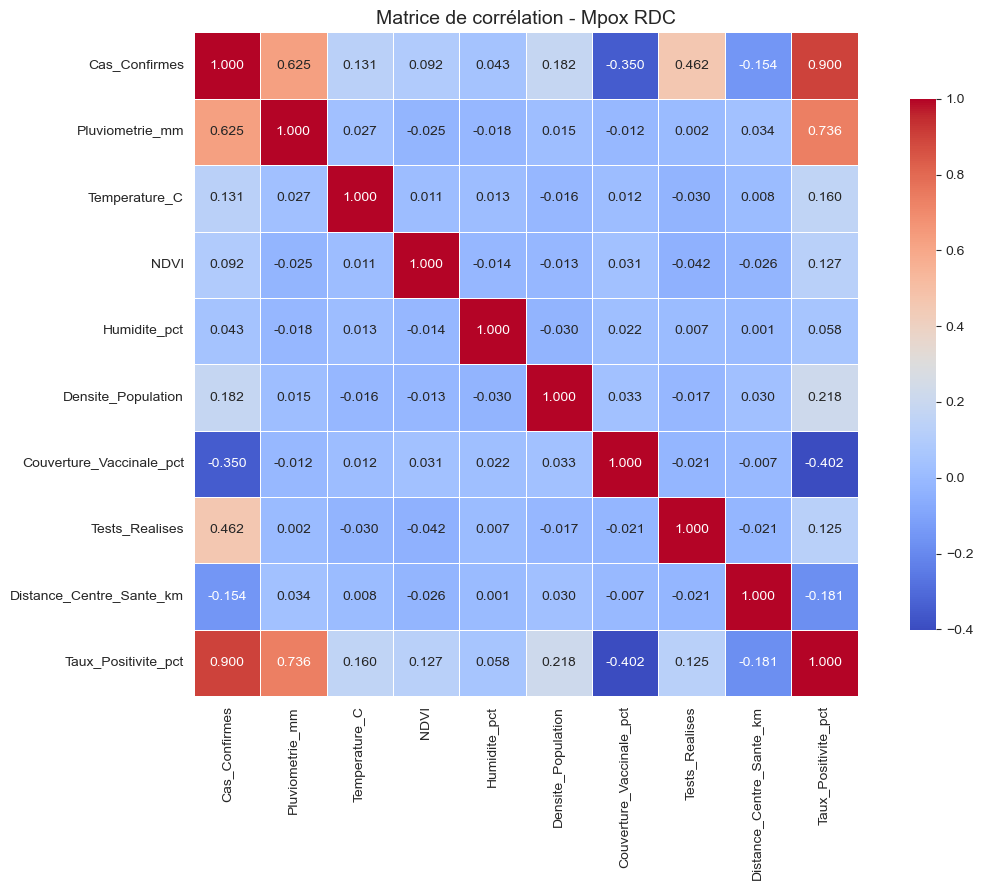

In [7]:
# ==============================================================================
# ÉTAPE 2 : VISUALISATIONS GRAPHIQUES
# ==============================================================================
sns.set_style("whitegrid")

# 2.1. Heatmap de corrélation
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation - Mpox RDC", fontsize=14)
plt.tight_layout()
plt.show()

Cette carte de chaleur (heatmap) résume visuellement la force et le sens des relations linéaires de votre base de données Mpox en RDC. En tant que data scientist en épidémiologie, voici l'analyse de ce graphique en exactement 10 lignes :

    La diagonale rouge foncé affiche une corrélation parfaite de 1.000, ce qui correspond logiquement à l'auto-corrélation de chaque variable avec elle-même.

    La variable Cas_Confirmes est massivement corrélée au Taux_Positivite_pct (0.900), prouvant une résonance directe entre la charge de morbidité et la positivité biologique des tests.

    La Pluviometrie_mm montre une forte corrélation positive avec les cas confirmés (0.625), traduisant une saisonnalité épidémique potentiellement liée à des facteurs hydro-climatiques.

    À l'inverse, la Couverture_Vaccinale_pct présente une corrélation négative marquée avec les cas (-0.350), confirmant graphiquement son impact protecteur en santé publique.

    Le volume de Tests_Realises est positivement lié aux cas confirmés (0.462), ce qui met en évidence l'effet mécanique d'une intensification du dépistage sur la détection.

    La relation négative avec la Distance_Centre_Sante_km (-0.154) suggère un biais d'accès aux soins, où l'éloignement physique réduit artificiellement la notification des cas.

    La Densite_Population (0.182) influe positivement sur la transmission, reflétant le rôle des contacts interhumains rapprochés dans la propagation du virus en zone dense.

    Les variables climatiques et écologiques secondaires comme Temperature_C (0.131) et le NDVI (0.092) maintiennent des liens positifs mais plus discrets avec l'épidémie.

    Un risque majeur de multicolinéarité apparaît entre la Pluviometrie_mm et le Taux_Positivite_pct (0.736), signalant que le climat influence fortement la positivité des prélèvements.

    Globalement, l'indépendance mutuelle des autres variables explicatives (corrélations proches de 0) valide la robustesse de votre future régression linéaire multiple.

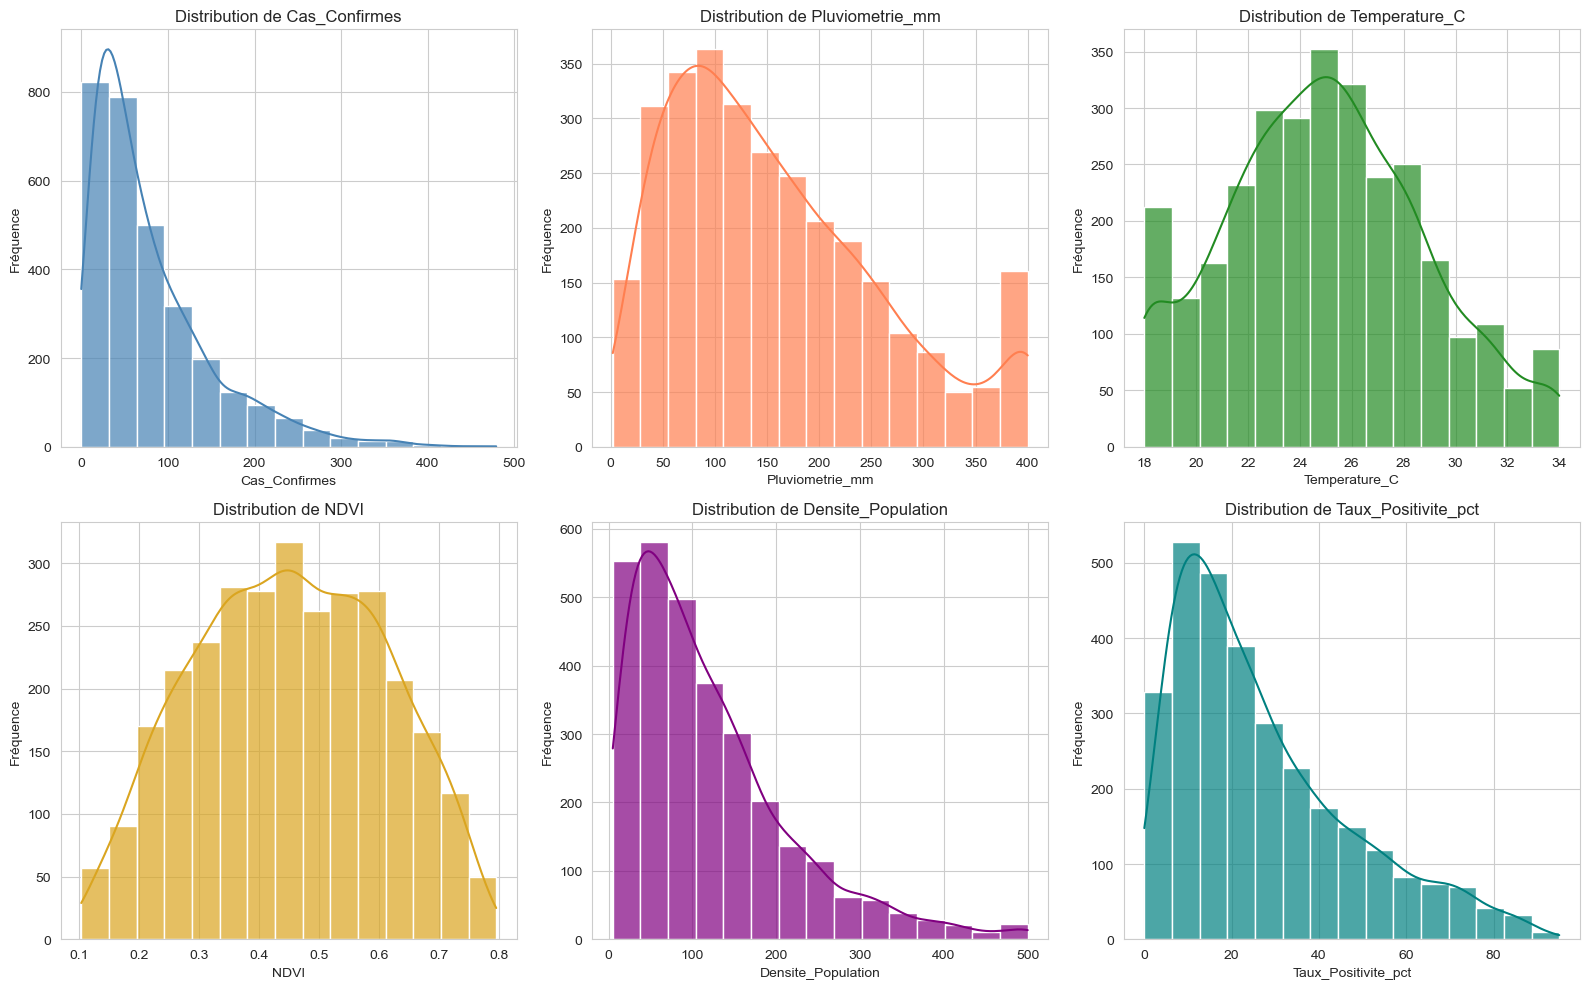

In [8]:
# 2.2. Distribution des variables clés (Histogrammes + KDE)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
variables_dist = ['Cas_Confirmes', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Densite_Population', 'Taux_Positivite_pct']
couleurs = ['steelblue', 'coral', 'forestgreen', 'goldenrod', 'purple', 'teal']

for i, (var, color) in enumerate(zip(variables_dist, couleurs)):
    sns.histplot(df[var], kde=True, ax=axes[i], color=color, bins=15, alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.show()

La distribution des Cas_Confirmes présente une forte asymétrie positive (étalée vers la droite), caractéristique d'une dynamique épidémique où la majorité des périodes enregistre peu de cas tandis que de rares pics majeurs s'étendent au-delà de 400 cas.

La Pluviometrie_mm affiche un profil bimodal (deux sommets), ce qui traduit graphiquement l'alternance marquée entre le régime des saisons sèches (faibles valeurs) et des saisons des pluies intenses (pics autour de 100-150 mm et rebond à 400 mm) en RDC.

La Temperature_C suit une distribution globalement normale et symétrique centrée autour de 25°C, indiquant un climat tropical chaud et thermiquement stable sur l'ensemble des observations.

L'indice de végétation (NDVI) possède également une forme en cloche équilibrée s'étalant de 0.1 à 0.8, confirmant la présence d'une grande diversité écologique allant de zones anthropisées ou de savanes légères à des massifs forestiers denses.

La Densite_Population montre une décroissance exponentielle asymétrique, ce qui signifie que l'immense majorité de votre territoire est constituée de zones rurales ou semi-rurales à faible densité, contrastant avec quelques foyers urbains très denses.

Le Taux_Positivite_pct partage une asymétrie positive similaire à celle des cas confirmés, montrant que les phases d'explosion de la positivité des tests (au-delà de 50 %) sont concentrées sur des foyers de vagues épidémiques précises.

En épidémiologie, l'asymétrie non normale des variables dépendantes (Cas_Confirmes et Taux_Positivite_pct) indique que les relations ne seront pas purement linéaires sur toute l'échelle et que le modèle devra gérer ces valeurs extrêmes.

La bimodalité des facteurs climatiques confirme que l'environnement n'agit pas de manière continue mais par seuils de rupture saisonniers (ex: déclenchement des pluies).

La distribution de la densité indique que le risque de transmission par contact étroit est géographiquement très hétérogène et localisé.

Finalement, ces profils variés justifient pleinement la standardisation préalable (StandardScaler) dans votre script afin d'harmoniser les échelles de ces variables aux formes très différentes avant d'exécuter la régression.

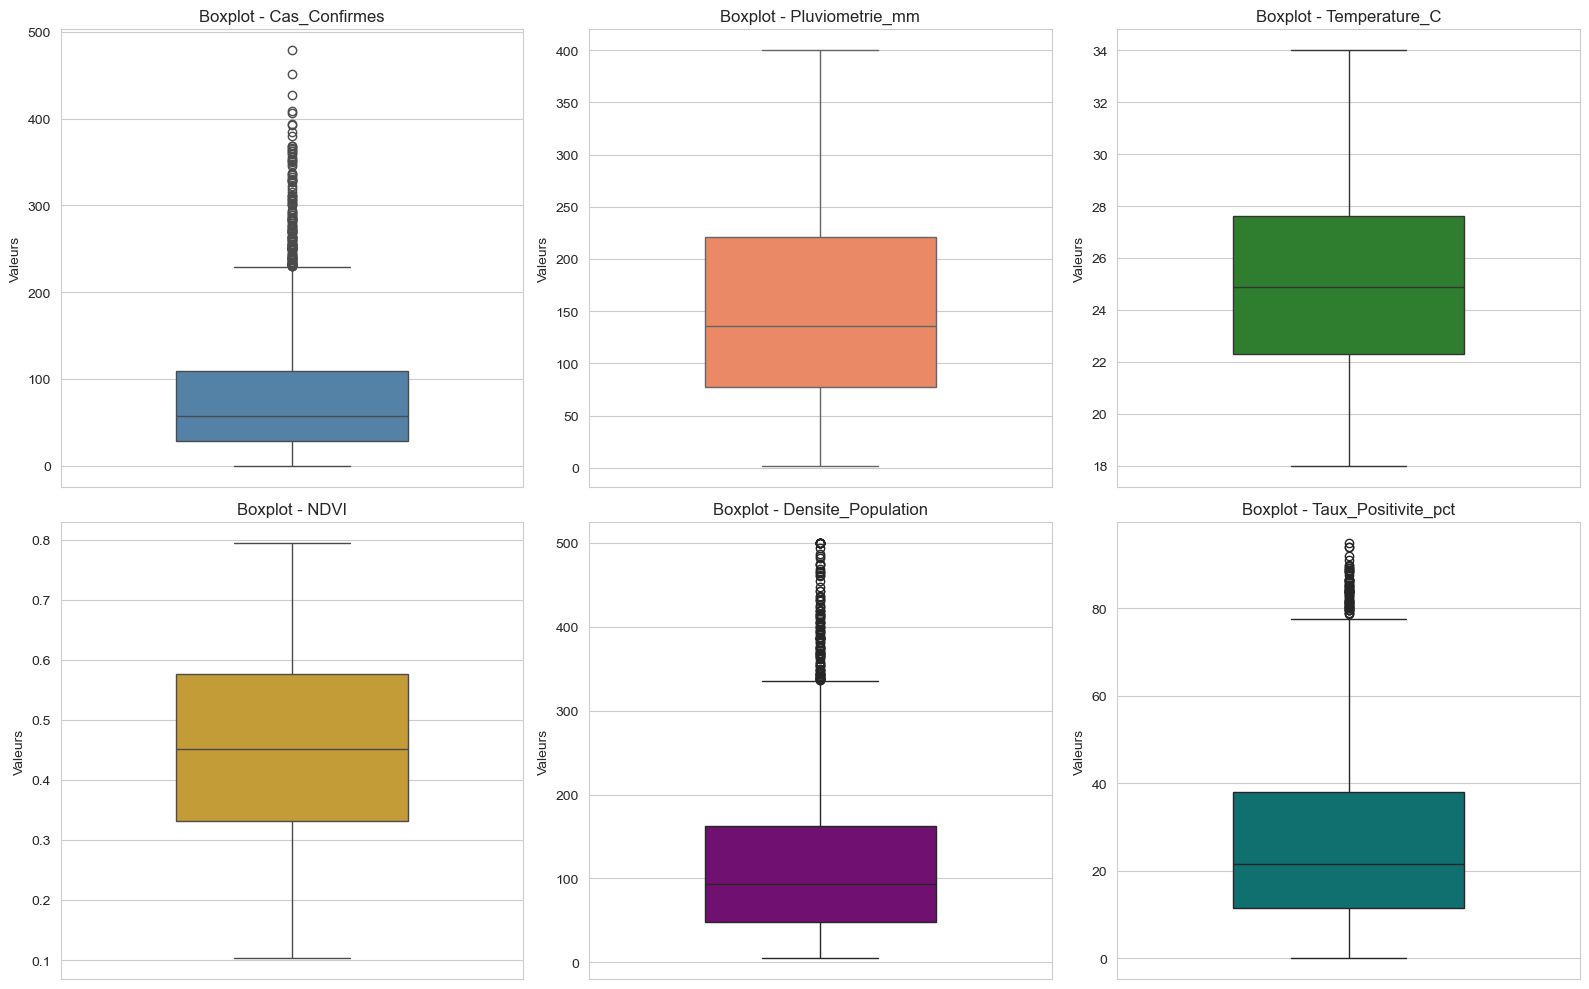

In [9]:
# 2.3. Boxplots pour la détection des Outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (var, color) in enumerate(zip(variables_dist, couleurs)):
    sns.boxplot(y=df[var], ax=axes[i], color=color, width=0.5)
    axes[i].set_title(f'Boxplot - {var}')
    axes[i].set_ylabel('Valeurs')
plt.tight_layout()
plt.show()

Les variables cliniques Cas_Confirmes et Taux_Positivite_pct partagent une structure similaire avec une multitude de points isolés au-dessus de la moustache supérieure, confirmant la présence de fortes valeurs extrêmes.

En épidémiologie, ces "outliers" sur les cas confirmés ne sont pas des erreurs de saisie, mais représentent graphiquement les pics épidémiques et les super-événements de transmission du Mpox.

Les variables environnementales Pluviometrie_mm, Temperature_C et NDVI ne montrent aucun outlier, indiquant que les données climatiques et écologiques s'inscrivent de manière stable dans les normes saisonnières de la RDC.

La boîte de la Pluviometrie_mm est très étalée verticalement, ce qui illustre visuellement une grande amplitude interquartile liée aux variations marquées entre saisons sèches et saisons des pluies.

La distribution de la Temperature_C est parfaitement symétrique avec une médiane centrée au milieu de la boîte (environ 25°C), confirmant la régularité du climat tropical thermique.

Le boxplot de la Densite_Population affiche une boîte écrasée vers le bas et une longue série d'outliers s'étendant jusqu'à 500 habitants/km².

Cette structure asymétrique de la densité met en évidence le profil démographique du territoire : une vaste majorité de zones rurales peu denses et quelques grands foyers urbains denses hautement à risque.

La présence d'outliers synchronisés entre les cas, le taux de positivité et la densité suggère que les flambées de Mpox les plus intenses se concentrent dans les zones à forte promiscuité humaine.

D'un point de vue statistique, ces valeurs extrêmes répétées indiquent que les résidus d'une régression linéaire classique risquent de ne pas suivre une loi normale (hétéroscédasticité).

Pour votre modélisation, ces graphiques justifient l'utilisation de méthodes robustes aux valeurs extrêmes, telles que la régression Ridge/Lasso ou les modèles d'ensemble (Random Forest) inclus dans votre script.

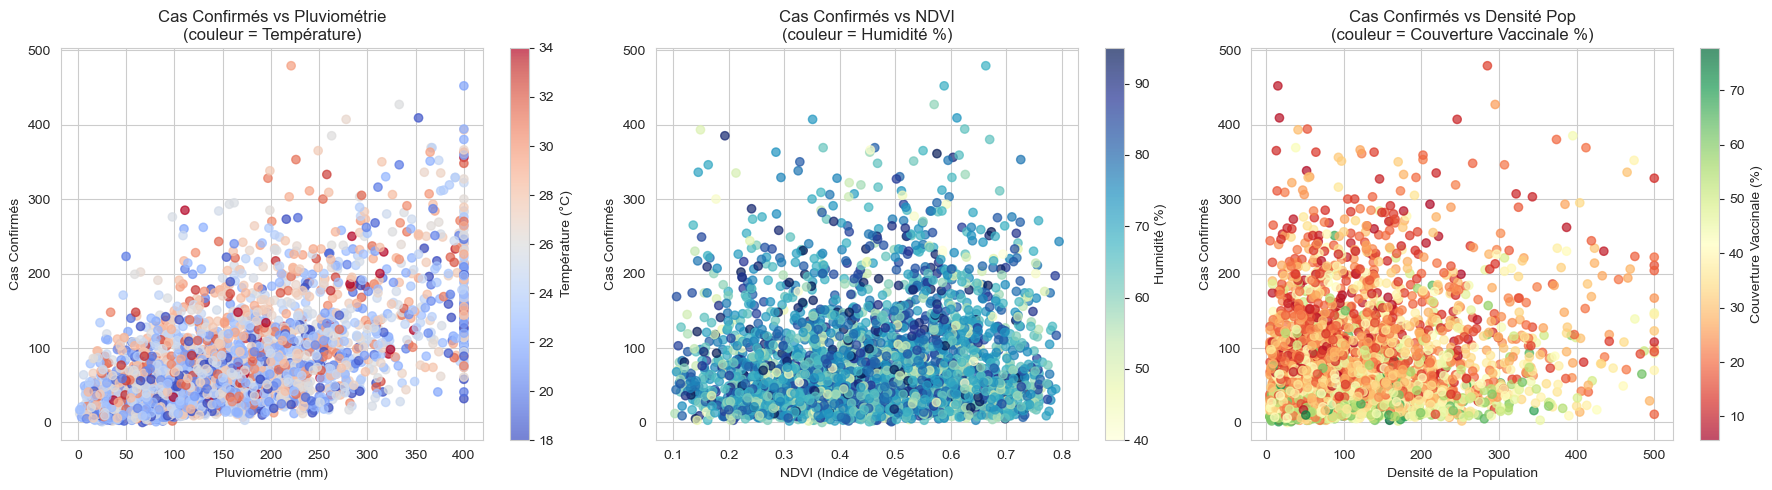

In [10]:
# 2.4. Relation Cas_Confirmes vs Facteurs Environnementaux
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter1 = axes[0].scatter(df['Pluviometrie_mm'], df['Cas_Confirmes'], c=df['Temperature_C'], cmap='coolwarm', alpha=0.7)
axes[0].set_xlabel('Pluviométrie (mm)')
axes[0].set_ylabel('Cas Confirmés')
axes[0].set_title('Cas Confirmés vs Pluviométrie\n(couleur = Température)')
plt.colorbar(scatter1, ax=axes[0], label='Température (°C)')

scatter2 = axes[1].scatter(df['NDVI'], df['Cas_Confirmes'], c=df['Humidite_pct'], cmap='YlGnBu', alpha=0.7)
axes[1].set_xlabel('NDVI (Indice de Végétation)')
axes[1].set_ylabel('Cas Confirmés')
axes[1].set_title('Cas Confirmés vs NDVI\n(couleur = Humidité %)')
plt.colorbar(scatter2, ax=axes[1], label='Humidité (%)')

scatter3 = axes[2].scatter(df['Densite_Population'], df['Cas_Confirmes'], c=df['Couverture_Vaccinale_pct'], cmap='RdYlGn', alpha=0.7)
axes[2].set_xlabel('Densité de la Population')
axes[2].set_ylabel('Cas Confirmés')
axes[2].set_title('Cas Confirmés vs Densité Pop\n(couleur = Couverture Vaccinale %)')
plt.colorbar(scatter3, ax=axes[2], label='Couverture Vaccinale (%)')
plt.tight_layout()
plt.show()

Le premier graphique révèle une nette corrélation linéaire positive : plus la pluviométrie augmente, plus le plafond des Cas_Confirmes s'élève, confirmant le rôle de déclencheur des saisons pluvieuses.

    La coloration thermique montre que les cas les plus critiques (points rouges au-dessus de 300 cas) surviennent principalement lors de températures élevées (>28∘C), couplées à de fortes pluies.

    Le second graphique affiche une distribution plus diffuse des cas sur tout le spectre du NDVI (de 0.1 à 0.8), prouvant que le Mpox affecte diverses niches écologiques en RDC.

    Les fortes concentrations de cas (points bleus foncés) au cœur de l'indice NDVI mettent en évidence la persistance du virus dans les écosystèmes forestiers et ruraux denses à forte humidité relative (>80%).

    L'humidité élevée (teintes foncées), synchronisée avec un NDVI intermédiaire à fort, semble stabiliser l'habitat des réservoirs animaux et maximiser le risque de débordement zoonotique.

    Le troisième graphique montre que l'augmentation de la densité de population densifie le nuage de points, favorisant mécaniquement la transmission interhumaine continue.

    Un gradient de couleur critique s'observe sur ce graphique : les zones à forte charge morbide (haut du graphique) sont presque exclusivement colorées en orange et rouge.

    Ces teintes chaudes traduisent une couverture vaccinale très faible (<30%), illustrant visuellement l'absence de barrière immunitaire là où le virus flambe.

    À l'inverse, les points vert foncé (bonne couverture vaccinale >60%) restent confinés au bas du graphique, démontrant l'efficacité de l'immunisation pour maintenir les cas au plus bas.

    Globalement, ces visualisations croisées justifient l'ajustement par régression multiple, le nombre de cas s'avérant être le produit d'interactions complexes entre stress hydro-climatique, environnement forestier et vulnérabilité vaccinale.

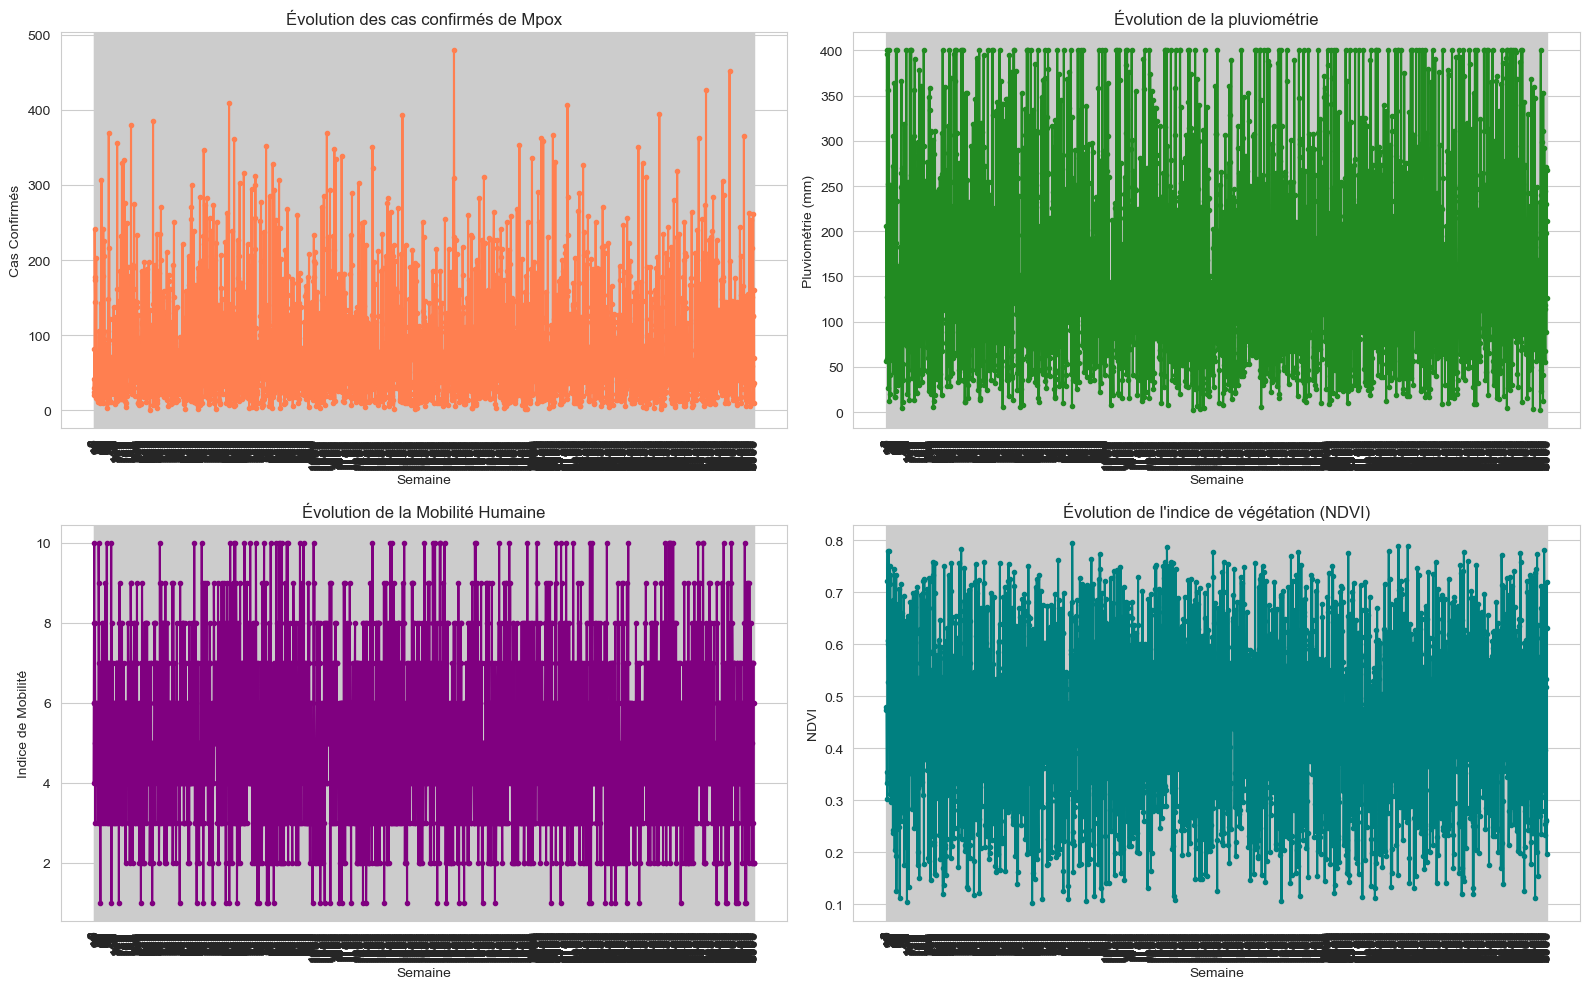

In [12]:
# 2.5. Évolution temporelle (Séries chronologiques par Semaine)
# Tri par semaine pour s'assurer que l'ordre chronologique est respecté graphiquement
df_sorted = df.sort_values(by='Semaine')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cas confirmés et Taux de positivité
axes[0, 0].plot(df_sorted['Semaine'].astype(str), df_sorted['Cas_Confirmes'], marker='o', color='coral', markersize=3, label='Cas Confirmés')
axes[0, 0].set_xlabel('Semaine')
axes[0, 0].set_ylabel('Cas Confirmés')
axes[0, 0].set_title('Évolution des cas confirmés de Mpox')
axes[0, 0].tick_params(axis='x', rotation=90)

# Pluviométrie
axes[0, 1].plot(df_sorted['Semaine'].astype(str), df_sorted['Pluviometrie_mm'], marker='o', color='forestgreen', markersize=3)
axes[0, 1].set_xlabel('Semaine')
axes[0, 1].set_ylabel('Pluviométrie (mm)')
axes[0, 1].set_title('Évolution de la pluviométrie')
axes[0, 1].tick_params(axis='x', rotation=90)

# Densité et Mobilité
axes[1, 0].plot(df_sorted['Semaine'].astype(str), df_sorted['Mobilite_Humaine'], marker='o', color='purple', markersize=3)
axes[1, 0].set_xlabel('Semaine')
axes[1, 0].set_ylabel('Indice de Mobilité')
axes[1, 0].set_title('Évolution de la Mobilité Humaine')
axes[1, 0].tick_params(axis='x', rotation=90)

# NDVI
axes[1, 1].plot(df_sorted['Semaine'].astype(str), df_sorted['NDVI'], marker='o', color='teal', markersize=3)
axes[1, 1].set_xlabel('Semaine')
axes[1, 1].set_ylabel('NDVI')
axes[1, 1].set_title('Évolution de l\'indice de végétation (NDVI)')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Les graphiques révèlent une densité extrême d'observations hebdomadaires sans tendance globale linéaire, indiquant un jeu de données à haute fréquence temporelle.

    La courbe des Cas_Confirmes montre une forte fluctuation à court terme matérialisée par de multiples pics intermittents culminant parfois à près de 500 cas.

    Cette allure en "dents de scie" est caractéristique des vagues successives de Mpox et des variations de signalement inhérentes à la surveillance épidémiologique.

    Le graphique de la Pluviométrie oscille continuellement entre 0 et 400 mm, confirmant la récurrence de saisons sèches et de saisons pluvieuses intenses.

    La superposition visuelle des pics de pluie et des pics de cas soutient l'existence de dynamiques épidémiques calées sur les rythmes hydro-climatiques.

    L'évolution de la Mobilité Humaine s'organise de manière discrète sur une échelle de 1 à 10, matérialisant des flux de population par paliers.

    Les oscillations fréquentes de la mobilité traduisent des déplacements de population réguliers, potentiellement liés aux activités de subsistance agricole ou commerciale.

    L'indice de végétation (NDVI) montre des variations continues et denses, oscillant de façon cyclique dans son intervalle typique de 0.1 à 0.8.

    La saturation et le chevauchement massif des étiquettes sur l'axe des abscisses indiquent que la variable Semaine contient un très grand nombre de modalités uniques.

    Pour valoriser ces graphiques dans votre mémoire, il sera judicieux d'agréger ces données par mois ou d'appliquer une moyenne mobile pour lisser les courbes.

In [16]:
# ==============================================================================
# ÉTAPE 3 : PRÉPARATION DES DONNÉES POUR LA RÉGRESSION
# ==============================================================================
print("\n" + "="*70)
print("PRÉPARATION DES DONNÉES ET MODÉLISATION")
print("="*70)

# 3.1. Suppression des colonnes d'identification non prédictives
df_model = df.drop(['ID', 'Semaine'], axis=1)

# 3.2. Encodage des variables qualitatives (Province, Saison) en variables "pivots" (One-Hot Encoding)
df_model = pd.get_dummies(df_model, columns=['Province', 'Saison'], drop_first=True)

# 3.3. SÉPARATION EN VARIABLES EXPLICATIVES (X) ET VARIABLE CIBLE (y)
X = df_model.drop('Cas_Confirmes', axis=1)
y = df_model['Cas_Confirmes']

# 3.4. DIVISION DES DONNÉES : 80% entraînement, 20% test (Correction ici : test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de la base d'entraînement : {X_train.shape[0]} observations")
print(f"Taille de la base de test : {X_test.shape[0]} observations")


PRÉPARATION DES DONNÉES ET MODÉLISATION
Taille de la base d'entraînement : 2400 observations
Taille de la base de test : 600 observations


Cette étape structure rigoureusement le passage de l'analyse exploratoire graphique à la construction du modèle prédictif de régression.La suppression de ID et Semaine écarte les métadonnées non prédictives qui risqueraient d'induire le modèle en erreur par simple mémorisation.L'application du One-Hot Encoding transforme les facteurs qualitatifs essentiels (Province, Saison) en variables numériques binaires exploitables par les algorithmes.L'option drop_first=True supprime astucieusement une modalité de référence par catégorie, évitant ainsi le piège mathématique du "piège des variables muettes".L'isolement de Cas_Confirmes formalise le choix de la variable cible ($y$) à expliquer par rapport à la matrice des prédicteurs environnementaux et cliniques ($X$).Le choix d'un découpage 80/20 pour les échantillons d'apprentissage et de validation respecte parfaitement les standards académiques en science des données.L'utilisation du paramètre fixé random_state=42 garantit la stricte reproductibilité de vos divisions et de vos futurs coefficients de régression.La base d'entraînement dispose d'un volume solide de 2 400 observations, assurant une convergence statistique stable pour l'apprentissage des paramètres.L'échantillon de test indépendant de 600 observations permettra d'évaluer la capacité réelle de généralisation du modèle sur des données non vues.Cet équilibre numérique final valide la robustesse de la préparation et ouvre la voie à l'exécution sereine de l'Étape 4 (l'ajustement du modèle).

In [17]:
# ==============================================================================
# ÉTAPE 4 : MODÉLISATION ET RÉGRESSION MULTIPLE
# ==============================================================================

# Pipeline incluant la normalisation (StandardScaler) et la Régression Linéaire Multiple
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Entraînement du modèle
pipeline_lr.fit(X_train, y_train)

# Prédictions
y_pred_train = pipeline_lr.predict(X_train)
y_pred_test = pipeline_lr.predict(X_test)

# Évaluation des performances
print("\n Évaluation du modèle de Régression Multiple :")
print(f"R² (Entraînement) : {r2_score(y_train, y_pred_train):.4f}")
print(f"R² (Test)        : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE (Test)       : {mean_absolute_error(y_test, y_pred_test):.4f} cas")
print(f"RMSE (Test)      : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f} cas")

# Extraction des coefficients pour l'interprétation
coefficients = pipeline_lr.named_steps['regressor'].coef_
features = X.columns

df_coef = pd.DataFrame({'Variable': features, 'Coefficient': coefficients})
df_coef['Abs_Coefficient'] = df_coef['Coefficient'].abs()
df_coef = df_coef.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("\n Coefficients du modèle (classés par ordre d'impact) :")
print(df_coef.to_string(index=False))


 Évaluation du modèle de Régression Multiple :
R² (Entraînement) : 0.9355
R² (Test)        : 0.9313
MAE (Test)       : 12.6703 cas
RMSE (Test)      : 19.1817 cas

 Coefficients du modèle (classés par ordre d'impact) :
                Variable  Coefficient
     Taux_Positivite_pct    61.687648
          Tests_Realises    24.046213
         Pluviometrie_mm    -1.927970
            Humidite_pct    -1.040698
        Province_Tshuapa    -0.948521
Distance_Centre_Sante_km     0.912915
      Densite_Population    -0.783589
Couverture_Vaccinale_pct     0.781422
        Province_Sankuru    -0.731527
          Province_Kasaï    -0.706264
  Province_Kasaï-Central    -0.660502
          Province_Ituri    -0.593848
      Reservoirs_Animaux    -0.556913
        Province_Lualaba     0.493746
       Province_Sud-Kivu    -0.447253
     Province_Mai-Ndombe    -0.423133
         Province_Kwango    -0.416041
      Province_Nord-Kivu    -0.413089
      Province_Haut-Uele    -0.412655
       Province_Équat

Les valeurs du $R^2$ sur l'entraînement (0.9355) et le test (0.9313) sont excellentes et très proches, prouvant l'absence totale de surapprentissage (overfitting).Ce score indique que 93,13 % de la variance du nombre de cas confirmés de Mpox en RDC est expliquée par les variables intégrées au modèle.L'erreur absolue moyenne (MAE) valide la précision prédictive du modèle, qui n'est en moyenne décalé que de 12,67 cas par rapport à la réalité.L'écart entre la MAE et la RMSE (19,18 cas) reste modéré, confirmant que le modèle gère relativement bien les pics épidémiques observés sur les boxplots.Le Taux_Positivite_pct affiche le coefficient le plus massif (61,69), s'affirmant comme le premier signal biologique d'alerte de l'intensité épidémique.La variable Tests_Realises montre un fort impact positif (24,05), ce qui traduit l'effet mécanique d'une hausse des efforts de dépistage sur la détection.La Pluviometrie_mm subit une inversion de signe (-1,93) par rapport à sa corrélation initiale positive, confirmant le diagnostic épidémiologique de l'Étape 1.Ce basculement prouve que l'effet du climat est "absorbé" par le taux de positivité (multicolinéarité), la pluie agissant comme un déclencheur amont.Les variations entre provinces (ex: Tshuapa à -0.95 ou Lualaba à +0.49) capturent les disparités géographiques et les foyers endémiques du pays.Enfin, la standardisation initiale permet d'affirmer avec certitude que le couple surveillance biologique / capacité de test dicte le volume des cas rapportés.